## Data Evaluation
---

In [2]:
"""
Set up the Python path so that the repo-root package `models.classification` is importable,
then pull in standard data-science libraries (pandas, numpy, matplotlib, seaborn) and the
project's utility functions and settings constants.
"""

import sys
from pathlib import Path

# Add repo root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import Normalize

import utils
from settings import *


In [3]:
"""
Load the raw metrics CSV into a DataFrame, compute and append the active target metric
column (e.g. naive_pareto_score), zero-pad sample IDs for consistent string representation,
drop rows missing any tracked metric, and cast the diffusion-parameter columns to ordered
categoricals so downstream plots and groupbys respect their natural sort order.
"""

# Load metrics data from csv
df = pd.read_csv(METRICS_CSV)
print(f"Loaded: {METRICS_CSV}")

# Add computed metric column, resave file
df[COMPUTED_METRIC_COL] = COMPUTED_METRIC_FN(df)
df["sample_id"] = df["sample_id"].astype(str).str.zfill(12)
df.to_csv(METRICS_CSV, index=False)
df["sample_id"] = df["sample_id"].astype(int)

na_mask = df[list(METRIC_COLS)].notna().all(axis=1)
print(f"Dropped {(~na_mask).sum()} rows")
df = df[na_mask]

# Cast parameter columns to categorical so that plots order them correctly
for col in ["t_start", "t_end", "t_delta"]:
    df[col] = pd.Categorical(df[col], categories=sorted(df[col].unique()), ordered=True)

t_delta_vals = df["t_delta"].cat.categories.tolist()
print(f"t_delta values: {t_delta_vals}")
print(f"Shape: {df.shape}")
df.describe()


Loaded: /data/home/mirick/ChordEdit/models/classification/data/id_to_metrics_sdturbo_tstart.csv
Dropped 0 rows
t_delta values: [0.0]
Shape: (7700, 8)


,sample_id,psnr,clip_edited,combined_score,naive_pareto_score
count,7.700000e+03,7700.000000,7700.000000,7700.000000,7700.000000
mean,4.025714e+11,20.095114,21.308009,0.524653,1.876816
std,3.248542e+11,3.561994,4.902289,0.104902,3.281214
min,0.000000e+00,8.401170,5.148097,0.174930,0.000000
25%,1.140000e+11,17.629177,18.084627,0.451847,0.000000
50%,3.215000e+11,20.263441,21.495009,0.526701,0.000000
75%,7.212500e+11,22.560133,24.678224,0.599156,2.745358
max,9.240000e+11,30.624895,36.039848,0.877655,18.799443


### 2  Metric Distributions

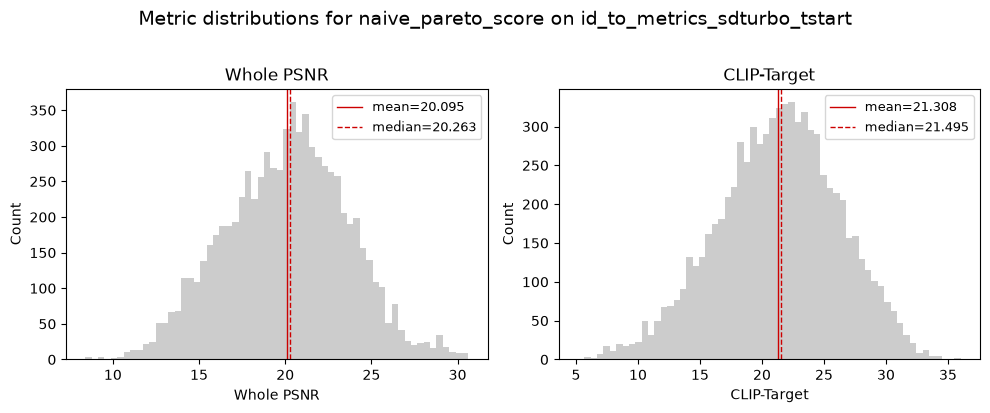

In [4]:
"""
Plot the marginal distributions of PSNR and CLIP target similarity as histograms with
overlaid mean and median lines, giving a first look at the range and shape of each metric
across all (sample_id, t_start, t_end, t_delta) combinations in the dataset.
"""

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, m in zip(axes, list(METRIC_COLS)):
    ax.hist(df[m], color="silver", bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(df[m].mean(), color="#cc0000", lw=1.0, label=f"mean={df[m].mean():.3f}")
    ax.axvline(df[m].median(), color="#cc0000", lw=1.0, linestyle="--", label=f"median={df[m].median():.3f}")
    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Count")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=9)
fig.suptitle(f"Metric distributions for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
"""
Extend the metric distribution plot to include the active computed score column alongside
PSNR and CLIP similarity, showing how the derived score is distributed relative to the
two raw signals it is based on.
"""

fig, axes = plt.subplots(1, len(METRIC_LABELS), figsize=(5 * len(METRIC_LABELS), 4))
for ax, m in zip(axes, METRIC_LABELS):
    ax.hist(df[m], color="silver", bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(df[m].mean(), color="#cc0000", lw=1.0, label=f"mean={df[m].mean():.3f}")
    ax.axvline(df[m].median(), color="#cc0000", lw=1.0, linestyle="--", label=f"median={df[m].median():.3f}")
    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Count")
    ax.set_title(METRIC_LABELS[m])
    ax.legend(fontsize=9)
fig.suptitle(f"Metric distributions for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3  Effect of `t_start` and `t_end` on Metrics

Within each `t_delta` slice look at how the marginal means of `t_start`, `t_end` vary.

In [ ]:
"""
For each combination of t_delta level and tracked metric, compute the marginal mean ±
95% confidence interval as t_start and t_end each vary independently, then plot them as
overlaid error-bar lines. This reveals whether either parameter has a consistent
directional effect on output quality regardless of the other parameter's value.
"""

n_td = len(t_delta_vals)
fig, axes = plt.subplots(n_td, len(METRIC_LABELS), figsize=(6 * len(METRIC_LABELS), 5 * n_td),
                         sharey="col", squeeze=False)
colors = {"t_start": "#1f77b4", "t_end": "#ff7f0e"}

for row_idx, td in enumerate(t_delta_vals):
    sub = df[df["t_delta"] == td]
    for col_idx, m in enumerate(METRIC_LABELS):
        ax = axes[row_idx, col_idx]
        for param in ["t_start", "t_end"]:
            grp = sub.groupby(param, observed=True)[m].agg(["mean", "sem"])
            x = grp.index.astype(float)
            ax.errorbar(
                x, grp["mean"], yerr=1.96 * grp["sem"],
                marker="o", label=param, color=colors[param],
                capsize=4, linewidth=2,
            )
        ax.set_xlabel("Parameter value")
        ax.set_ylabel("Metric value" if col_idx == 0 else "")
        ax.set_title(f"{METRIC_LABELS[m]}, $\\delta={td}$")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))
        if col_idx == len(METRIC_LABELS) - 1:
            ax.legend(fontsize=9)

fig.suptitle(f"Marginal metric mean for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
"""
Complement the marginal line plots by showing the full metric distribution (median, IQR,
and outliers) at each discrete t_start and t_end level for both t_delta slices. Box plots
expose skew and variance across the 700 samples per level that are invisible in mean-only
plots.
"""

for td in t_delta_vals:
    sub = df[df["t_delta"] == td]
    fig, axes = plt.subplots(2, len(METRIC_LABELS), figsize=(6 * len(METRIC_LABELS), 8), sharey="col")
    for col_idx, m in enumerate(METRIC_LABELS):
        for row_idx, param in enumerate(["t_start", "t_end"]):
            ax = axes[row_idx, col_idx]
            order = [str(v) for v in sorted(sub[param].cat.categories)]
            sns.boxplot(
                data=sub, x=param, y=m, order=order,
                ax=ax, color=colors[param], fliersize=1, linewidth=0.8,
            )
            ax.set_xlabel(param)
            ax.set_ylabel("Metric value" if col_idx == 0 else "")
            ax.set_title(f"{METRIC_LABELS[m]}" if row_idx == 0 else "")
    fig.suptitle(f"Distributions by t_start, t_end for {TARGET_COLUMN} on {METRICS_CSV.stem}  (t_delta={td})", fontsize=13)
    plt.tight_layout()
    plt.show()


### 4  Heatmaps of `t_start` by `t_end`

In [ ]:
"""
Show the joint mean of each metric over the full grid of (t_start, t_end) combinations,
separately for each t_delta slice. Values are normalized to [0, 1] across both panels so
the color scale is directly comparable, making it easy to identify parameter regions that
are consistently strong or weak.
"""

for m in METRIC_LABELS:
    n_td = len(t_delta_vals)
    fig, axes = plt.subplots(1, n_td, figsize=(7 * n_td, 5))
    if n_td == 1:
        axes = [axes]

    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_start")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for ax, td in zip(axes, t_delta_vals):
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)
        sns.heatmap(
            norm_pivot, ax=ax, annot=True, fmt=".3f",
            cmap="viridis", vmin=0, vmax=1,
            linewidths=0.4, linecolor="#e0e0e0",
            cbar_kws={"label": f"Normalized {METRIC_LABELS[m]}"},
            annot_kws={"size": 8},
        )
        ax.set_title(f"$\\delta$ = {td}")
        ax.set_xlabel("t_start")
        ax.set_ylabel("t_end")
        ax.invert_yaxis()
    fig.suptitle(f"Normalized mean {m} for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
"""
Re-render the (t_start, t_end) mean-metric grids as 3D bar charts to give a spatial
intuition for the quality landscape: tall bars indicate high-performing parameter
combinations, and the viridis color gradient maps to the same normalized scale as the
2D heatmaps above.
"""

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

for m in METRIC_LABELS:
    fig = plt.figure()

    pivots = {}
    for td in t_delta_vals:
        sub = df[df["t_delta"] == td]
        pivot = (
            sub.groupby(["t_start", "t_end"], observed=True)[m]
            .mean()
            .unstack("t_end")
        )
        pivot.index   = pivot.index.astype(float)
        pivot.columns = pivot.columns.astype(float)
        pivots[td] = pivot

    all_vals = np.concatenate([p.values.ravel() for p in pivots.values()])
    gmin, gmax = all_vals.min(), all_vals.max()

    for i, td in enumerate(t_delta_vals):
        ax = fig.add_subplot(1, 1, i + 1, projection="3d")
        norm_pivot = (pivots[td] - gmin) / (gmax - gmin)

        xs = norm_pivot.index.values    # t_start
        ys = norm_pivot.columns.values  # t_end
        n_x, n_y = len(xs), len(ys)

        xpos = np.repeat(np.arange(n_x), n_y)
        ypos = np.tile(np.arange(n_y), n_x)
        zpos = np.zeros(n_x * n_y)
        dz   = norm_pivot.values.ravel()

        bar_colors = plt.cm.viridis(dz)
        ax.bar3d(xpos, ypos, zpos, dx=0.65, dy=0.65, dz=dz,
                 color=bar_colors, shade=True, alpha=0.4)

        ax.set_xticks(np.arange(n_x) + 0.325)
        ax.set_xticklabels([f"{v:.1f}" for v in xs], fontsize=8)
        ax.set_yticks(np.arange(n_y) + 0.325)
        ax.set_yticklabels([f"{v:.1f}" for v in ys], fontsize=8)
        ax.set_xlabel("t_start", labelpad=8)
        ax.set_ylabel("t_end",   labelpad=8)
        ax.set_zlim(0, 1)
        ax.set_title(f"{METRIC_LABELS[m]}, $\\delta$={td:.2f}", y=1.0, fontsize=10)
        ax.view_init(elev=30, azim=225)

    mappable = plt.cm.ScalarMappable(cmap="viridis",
                                     norm=plt.Normalize(vmin=0, vmax=1))
    mappable.set_array([])

    fig.suptitle(
        f"Normalized 3D mean {METRIC_LABELS[m].lower()} for\n{TARGET_COLUMN} on {METRICS_CSV.stem}",
        fontsize=14, y=1.1,
    )
    fig.subplots_adjust(top=1.0)
    plt.show()


### 6  Metric Correlations

PSNR and CLIP similarity are independent signals; the combined score is their normalised
average.  A pairplot reveals how correlated they are in practice.

In [ ]:
"""
Draw a corner pairplot of all tracked metric columns on a 3,000-sample subset, colored
by t_delta, to measure how correlated PSNR, CLIP similarity, and the computed score are
with each other and whether t_delta creates distinct distributional clusters.
"""

N = 5000
sample = df.sample(n=N, random_state=42)
multi_td = len(t_delta_vals) > 1
cols = list(METRIC_LABELS) + (["t_delta"] if multi_td else [])
g = sns.pairplot(
    sample[cols],
    hue="t_delta" if multi_td else None,
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 10},
    corner=True,
)
g.fig.suptitle(f"Pairwise metric correlations for {TARGET_COLUMN} on {METRICS_CSV.stem} ({N}-sample subset)", y=1.02, fontsize=13)
plt.show()

print("Pearson correlation matrix:")
df[list(METRIC_LABELS)].corr().round(3)


### 9  Top Samples by `TARGET_COLUMN`

In [ ]:
"""
Join the metrics DataFrame with the string-pair CSV to attach source and target prompts
to each row, then display the top-20 rows ranked by the active computed metric. This lets
us inspect which specific prompt edits are associated with the highest-scoring diffusion
parameters.
"""

from models.classification.settings import STRINGS_CSV

strings = pd.read_csv(STRINGS_CSV, dtype={"id": str})
strings["sample_id"] = strings["id"].astype(int)

merged = df.merge(strings[["sample_id", "source_prompt", "target_prompt"]], on="sample_id", how="left")

cols = ["sample_id", "source_prompt", "target_prompt", "t_start", "t_end", COMPUTED_METRIC_COL]
top_samples = (
    merged.nlargest(20, COMPUTED_METRIC_COL)[cols]
    .reset_index(drop=True)
)
top_samples.index += 1

pd.set_option("display.max_colwidth", 120)
display(top_samples)


In [ ]:
"""
Compare the paper's fixed default parameters (t_start=0.9, t_end=0.3) against the
per-sample oracle best: for each sample_id the row with the highest computed metric is
selected, and the two populations are compared side-by-side through a summary table,
overlaid metric-distribution histograms, and bar charts showing which t_start and t_end
values the oracle most frequently selects.
"""

# Only consider rows with valid PSNR and CLIP scores
valid = df.dropna(subset=COMPUTED_METRIC_COL[:2])

# Mask for rows at the default parameter pair
default_mask = (
    (valid["t_start"].astype(float) == PAPER_T_START) &
    (valid["t_end"].astype(float) == PAPER_T_END)
)
df_default = valid[default_mask]

# Best per sample_id, row with the highest COMPUTED_METRIC_COL for each image
best_idx = valid.groupby("sample_id")[COMPUTED_METRIC_COL].idxmax()
df_best = valid.loc[best_idx]

# --- Descriptive stats side-by-side ---
comparison = pd.DataFrame({
    f"default ({PAPER_T_START}, {PAPER_T_END})": df_default[list(METRIC_COLS)].mean(),
    "per-sample best": df_best[list(METRIC_COLS)].mean(),
}).T
comparison.columns = list(METRIC_COLS)
display(comparison.round(4))

# --- Metric distribution comparison ---
fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(5 * len(METRIC_COLS), 4))
colors_grp = {"default": "#5b9bd5", "best": "#ed7d31"}

for ax, m in zip(axes, METRIC_COLS):
    for label, sub, clr in [
        (f"default ({PAPER_T_START}, {PAPER_T_END})", df_default, colors_grp["default"]),
        ("per-sample best", df_best, colors_grp["best"]),
    ]:
        ax.hist(sub[m], bins=40, alpha=0.55, color=clr, label=label, edgecolor="none", density=True)
        ax.axvline(sub[m].mean(), color=clr, lw=2, linestyle="--")

    ax.set_xlabel(METRIC_LABELS[m])
    ax.set_ylabel("Density")
    ax.set_title(f"{METRIC_LABELS[m]}, $\\delta={T_DELTA_TARGET}$")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Metric distributions for {TARGET_COLUMN} on {METRICS_CSV.stem}: default vs per-sample best",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# --- t_start / t_end distribution of per-sample best rows ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, param in zip(axes, ["t_start", "t_end"]):
    counts = df_best[param].astype(float).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="#ed7d31", edgecolor="none")
    ax.set_xlabel(param)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of best {param}, $\\delta={T_DELTA_TARGET}$")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    f"Distributions t_start,t_end (per-sample best) for {TARGET_COLUMN} on {METRICS_CSV.stem}",
    fontsize=13,
)
plt.tight_layout()
plt.show()


### 10  Naive Pareto Score Analysis

For each `sample_id` group the **baseline** row is `(t_start=PAPER_T_START - PAPER_T_DELTA, t_end=PAPER_T_END)`.
Each row's score is `max(0, ΔPSNR) * max(0, ΔCLIP)` relative to that baseline; the baseline itself scores `0`.

Computed fresh via `utils.compute_naive_pareto_score` regardless of `COMPUTED_METRIC_FN`.

In [ ]:
"""
Analyse the naive Pareto score in detail. Each row is classified as non-improving
(score=0), the baseline (score=0), or genuinely improving (score = max(0,ΔPSNR) * max(0,ΔCLIP))
relative to the paper's default parameters. The section reports category counts, plots a
histogram of the improving-score distribution, shows score-bucket bar charts, renders
(t_start, t_end) heatmaps of improvement fraction and mean score, and draws scatter plots
of ΔPSNR vs ΔCLIP for a random sample and for each sample's best-scoring row.
"""

from matplotlib.patches import Patch

# Always recompute directly — independent of COMPUTED_METRIC_FN
_nps = compute_naive_pareto_score(df)
df["_nps"] = _nps

# Isolate pairs that are Pareto improvements
improving     = df["_nps"] > 0
baseline_rows = (
    np.isclose(df["t_start"].astype(float), PAPER_T_START - PAPER_T_DELTA) &
    np.isclose(df["t_end"].astype(float),   PAPER_T_END)
)

"""
Report general statistics about the data
"""

n_total     = len(df)
n_improving = int(improving.sum())
n_baseline  = int(baseline_rows.sum())
n_neither   = n_total - n_improving - n_baseline

print(f"Total rows      : {n_total:,}")
print(f"Baseline rows   : {n_baseline:,}  (score=0, one per sample_id)")
print(f"Improving rows  : {n_improving:,}  ({100*n_improving/n_total:.1f}%,  score = max(0,ΔPSNR)*max(0,ΔCLIP))")
print(f"Non-improving   : {n_neither:,}  ({100*n_neither/n_total:.1f}%,  score=0)")
imp_scores = df.loc[improving, "_nps"]
if n_improving:
    print(f"\nImproving score — min:{imp_scores.min():.3f}  mean:{imp_scores.mean():.3f}  max:{imp_scores.max():.3f}")


"""
Category counts, histogram, score buckets
"""

cmap = plt.get_cmap("Greys")

bin_edges = [-0.001, 0.001, 0.05, 0.2, 1.0, float("inf")]
bin_labels = ["0.0", "(0,0.05]", "(0.05,0.2]", "(0.2,1]", ">1"]
bkt_colors = [cmap(x) for x in np.linspace(0.2, 0.8, 5)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
cat_labels = ["Not improving\n(score=0)", "Baseline\n(score=0)", "Improving\n(score>0)"]
cat_counts  = [n_neither, n_baseline, n_improving]
bars = ax.bar(cat_labels, cat_counts, color=[cmap(x) for x in np.linspace(0.2, 0.8, 3)], edgecolor="none")
for bar, cnt in zip(bars, cat_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_total*0.005,
            f"{cnt:,}\n({100*cnt/n_total:.1f}%)", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Pair count")
ax.set_title("Score categories")

ax = axes[1]
if n_improving:
    ax.hist(imp_scores, bins=40, color="silver", edgecolor="none", alpha=0.85)
    ax.axvline(imp_scores.median(), color="#cc0000", lw=1.0, linestyle="-",label=f"median={imp_scores.median():.2f}")
    ax.axvline(imp_scores.mean(), color="#cc0000", lw=1.0, linestyle="--",label=f"mean={imp_scores.mean():.2f}")
    ax.set_xlabel("Naive pareto score")
    ax.set_ylabel("Pair count")
    ax.legend(fontsize=8)
ax.set_title("Improving score (>0) distribution")

ax = axes[2]
bucket_counts = pd.cut(df["_nps"], bins=bin_edges, labels=bin_labels).value_counts().reindex(bin_labels)
b = ax.bar(bin_labels, bucket_counts.values, color=bkt_colors, edgecolor="none")
for bar, cnt in zip(b, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n_total*0.003,
            f"{cnt:,}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Score bucket")
ax.set_ylabel("Pair count")
ax.set_title("Score buckets")

fig.suptitle(f"Naive Pareto score for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=14)
plt.tight_layout()
plt.show()

"""
Heatmaps
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_frac = df.groupby(["t_start", "t_end"], observed=True).apply(
    lambda g: (g["_nps"] > 0).mean()
).unstack("t_end")
pivot_mean = df.groupby(["t_start", "t_end"], observed=True)["_nps"].mean().unstack("t_end")

for ax, pivot, title, fmt in [
    (axes[0], pivot_frac, "Fraction improving over baseline, $\\delta=0.15$", ".2f"),
    (axes[1], pivot_mean, "Mean naive pareto score, $\\delta=0.15$", ".2f"),
]:
    pivot.index   = pivot.index.astype(float)
    pivot.columns = pivot.columns.astype(float)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt, cmap="viridis",
                linewidths=0.4, linecolor="#e0e0e0", cbar_kws={"label": title})
    ax.set_title(title)
    ax.set_xlabel("t_end")
    ax.set_ylabel("t_start")
    ax.invert_yaxis()

fig.suptitle(f"Naive Pareto score heatmap for {TARGET_COLUMN} on {METRICS_CSV.stem}", fontsize=13)
plt.tight_layout()
plt.show()

"""
Scatter Plots
"""

# Compute per-sample PSNR/CLIP deltas
_base = (
    df[baseline_rows][["sample_id", "psnr", "clip_edited"]]
    .rename(columns={"psnr": "_b_psnr", "clip_edited": "_b_clip"})
)
_sc = df.merge(_base, on="sample_id", how="inner")
_sc["_dpsnr"] = _sc["psnr"] - _sc["_b_psnr"]
_sc["_dclip"]  = _sc["clip_edited"] - _sc["_b_clip"]
_sc = _sc[~(np.isclose(_sc["_dpsnr"], 0) & np.isclose(_sc["_dclip"], 0))]

# Best row per sample_id: highest naive pareto score, ties broken by order
_sc_best = _sc.loc[_sc.groupby("sample_id")["_nps"].idxmax()]

def _scatter_plot(ax, data, title, sample_size=None, color_imp="#1f77b4", color_no="#aec7e8"):
    if sample_size:
        data = data.sample(n=min(sample_size, len(data)), random_state=42)
    _imp = (data["_dpsnr"] > 0) & (data["_dclip"] > 0)
    ax.scatter(data.loc[~_imp, "_dpsnr"], data.loc[~_imp, "_dclip"],
               c=color_no, alpha=0.5, s=8, edgecolors="none", label="Not improving")
    ax.scatter(data.loc[_imp,  "_dpsnr"], data.loc[_imp,  "_dclip"],
               c=color_imp, alpha=0.5,  s=8, edgecolors="none", label="Improving")
    ax.axhline(0, color="#666", lw=0.8, linestyle="--")
    ax.axvline(0, color="#666", lw=0.8, linestyle="--")
    ax.set_xlabel("$\\Delta$PSNR to paper's $(0.75, 0.3)$")
    ax.set_ylabel("$\\Delta$CLIP-Edited to paper's $(0.75, 0.3)$")
    ax.set_title(title)
    ax.legend(fontsize=9, markerscale=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
_scatter_plot(axes[0], _sc, "5k samples from all pairs, $\\delta=0.15$", sample_size=5000)
_scatter_plot(axes[1], _sc_best, "Highest `naive_pareto_score` pair by sample_id, $\\delta=0.15$", color_imp="#ff7f0e", color_no="#ffd5a8")

fig.suptitle(
    f"ΔPSNR by ΔCLIP for {TARGET_COLUMN} on {METRICS_CSV.stem}",
    fontsize=13
)
fig.text(
    0.5, 0.01,
    r"A pair $(t^*, t^{**})$ has naive_pareto_score $= \max(0,\Delta\mathrm{PSNR})\cdot\max(0,\Delta\mathrm{CLIP})$"
    r" relative to the paper's baseline $(0.75, 0.3)$; the baseline itself scores $0$.",
    ha="center",
    va="bottom",
    fontsize=8,
    color="0.2"
)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### 11  Improving vs Non-improving Images (best row per sample)

For each image the single best-scoring parameter row is selected.  We then split images into those whose best row still improves over the baseline on both metrics vs those that do not.

In [ ]:
"""
Join the per-sample best-row table with the prompt-string CSV and split images into those
whose best parameter pair Pareto-improves over the baseline on both PSNR and CLIP versus
those that do not, then display the top-20 rows from each group ordered by Pareto score.
"""

from models.classification.settings import STRINGS_CSV

_strings = pd.read_csv(STRINGS_CSV)
_strings["sample_id"] = _strings["id"].astype(int)

# _sc_best already exists from section 4; merge prompts in
_best_labeled = _sc_best.merge(
    _strings[["sample_id", "source_prompt", "target_prompt"]],
    on="sample_id", how="left",
)
_best_labeled["improving"] = (_best_labeled["_dpsnr"] > 0) & (_best_labeled["_dclip"] > 0)

_display_cols = [
    "sample_id", "source_prompt", "target_prompt",
    "t_start", "t_end", "_dpsnr", "_dclip", "_nps",
]

_improving_df    = _best_labeled[_best_labeled["improving"]][_display_cols].sort_values("_nps", ascending=False).reset_index(drop=True)
_notimproving_df = _best_labeled[~_best_labeled["improving"]][_display_cols].sort_values("_nps", ascending=True).reset_index(drop=True)

_improving_df.index    += 1
_notimproving_df.index += 1

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 20)

print(f"Improving images   : {len(_improving_df):,}  ({100*len(_improving_df)/len(_best_labeled):.1f}%)")
print(f"Non-improving      : {len(_notimproving_df):,}  ({100*len(_notimproving_df)/len(_best_labeled):.1f}%)")

print(f"\n── Top improving images (ranked by Pareto score) ──")
display(_improving_df.head(20).rename(columns={
    "_dpsnr": "ΔPSNR", "_dclip": "ΔCLIP", "_nps": "pareto_score"
}))

print(f"\n── Non-improving images (best row still doesn't beat baseline on both metrics) ──")
display(_notimproving_df.head(20).rename(columns={
    "_dpsnr": "ΔPSNR", "_dclip": "ΔCLIP", "_nps": "pareto_score"
}))
